## importing librarys and load data

In [1]:
import numpy as np 
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt
import warnings
from sklearn.preprocessing import MinMaxScaler,OrdinalEncoder
from tensorflow.keras import Sequential
from tensorflow.keras.layers import *
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import L2
from tensorflow.keras.callbacks import EarlyStopping , ModelCheckpoint
from sklearn.metrics import mean_squared_error as mse
from sklearn.model_selection import train_test_split
warnings.filterwarnings('ignore')


In [2]:
df = pd.read_excel(r"Online Retail.xlsx")

## Data Preprocessing & Feature engineering


In [6]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [8]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [10]:
df = df[~df['InvoiceNo'].astype('str').str.startswith('C')]

In [11]:
print(df.duplicated().sum() , "duplicated value")
df = df.drop_duplicates()

5231 duplicated value


## handiling missing values

In [14]:
max_id = df.CustomerID.max()
null_ids = df.CustomerID.isna()
null_ids = null_ids[null_ids == True]
df.loc[null_ids.index,'CustomerID'] = np.arange(max_id + 1,max_id + null_ids.sum() + 1)

In [17]:
df.CustomerID.isna().sum()

0

In [19]:
print(df.isna().sum().sum())
df.dropna(inplace=True)

1454


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 525936 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    525936 non-null  object        
 1   StockCode    525936 non-null  object        
 2   Description  525936 non-null  object        
 3   Quantity     525936 non-null  int64         
 4   InvoiceDate  525936 non-null  datetime64[ns]
 5   UnitPrice    525936 non-null  float64       
 6   CustomerID   525936 non-null  float64       
 7   Country      525936 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 36.1+ MB


In [23]:
df=df[df['Quantity']>0]
df = df[df['UnitPrice'] > 0]

In [25]:
df['total_price']=df['Quantity']*df['UnitPrice']

In [27]:
df['total_price'] = df['total_price'].clip(lower=0)

### Create RFM features: 

In [30]:
# create RFM Recency Frequency Monetary features
snapshot_date=df['InvoiceDate'].max()+ pd.Timedelta(days=1)
df['Recency']=df.groupby('CustomerID')['InvoiceDate'].transform(lambda x:(snapshot_date-x.max()).days)

df['Frequency']=df.groupby('CustomerID')['InvoiceNo'].transform('nunique')

df['Monetary']=df.groupby('CustomerID')['total_price'].transform('sum')

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 524878 entries, 0 to 541908
Data columns (total 12 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    524878 non-null  object        
 1   StockCode    524878 non-null  object        
 2   Description  524878 non-null  object        
 3   Quantity     524878 non-null  int64         
 4   InvoiceDate  524878 non-null  datetime64[ns]
 5   UnitPrice    524878 non-null  float64       
 6   CustomerID   524878 non-null  float64       
 7   Country      524878 non-null  object        
 8   total_price  524878 non-null  float64       
 9   Recency      524878 non-null  int64         
 10  Frequency    524878 non-null  int64         
 11  Monetary     524878 non-null  float64       
dtypes: datetime64[ns](1), float64(4), int64(3), object(4)
memory usage: 52.1+ MB


In [32]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,total_price,Recency,Frequency,Monetary
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,372,34,5391.21
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,372,34,5391.21
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,372,34,5391.21
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,372,34,5391.21
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,372,34,5391.21


## Create CLV

#### before CLV

In [35]:
df['AverageOrderValue'] = df['Monetary'] / df['Frequency']  

In [36]:
df['FirstPurchase'] = df.groupby('CustomerID')['InvoiceDate'].transform('min')
df['LastPurchase'] = df.groupby('CustomerID')['InvoiceDate'].transform('max')

df['CustomerAgeDays'] = (df['LastPurchase'] - df['FirstPurchase']).dt.days + 1 
df['CustomerAgeMonth'] = df['CustomerAgeDays'] / 30

In [37]:
df['FrequencyPerMonth'] = df['Frequency'] / df['CustomerAgeMonth']

In [38]:
df['RecencyMonth'] = df['Recency']/30

In [39]:
df['CLV'] = df['FrequencyPerMonth'] * df['AverageOrderValue'] * 3 # 3 is customer lifespan
df['CLV'] = df['CLV'] * (1/( df['RecencyMonth']+1)) # make the CLV related to new customers

### add important features for model to predict CLV 

In [41]:
#n.of differnt product that the customer buy
df['ProductDiversity'] = df.groupby('CustomerID')['StockCode'].transform('nunique') 

In [42]:
# dictionary for each category
category_keywords = {
    "Fashion": ["bag", "dress", "shirt","shoes", "jacket", "coat"],
    "Home": [ "bunting", "holder","candle", "lamp", "light"],
    "Kitchen": ["cakestand", "cup", "mug", "plate", "knife", "fork", "spoon", "kettle", "bottle", "glass"],
    "Stationery": ["card", "craft", "letter","notebook", "pen", "pencil"],
    "Accessories": ["key ring", "bling","jewelry","ring"]
}
# function
def extract_category(text):
    text = str(text).lower()
    for category, keywords in category_keywords.items():
        if any(word in text for word in keywords):
            return category
    return "Other"

#identify product category 
df['ProductCategory'] = df['Description'].apply(extract_category)

In [43]:
df['ProductCategory'].unique()

array(['Home', 'Other', 'Fashion', 'Kitchen', 'Stationery', 'Accessories'],
      dtype=object)

In [55]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,total_price,Recency,...,AverageOrderValue,FirstPurchase,LastPurchase,CustomerAgeDays,CustomerAgeMonth,FrequencyPerMonth,RecencyMonth,CLV,ProductDiversity,ProductCategory
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,372,...,158.565,2010-12-01 08:26:00,2010-12-02 15:27:00,2,0.066667,510.0,12.4,18104.809701,21,Home
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,372,...,158.565,2010-12-01 08:26:00,2010-12-02 15:27:00,2,0.066667,510.0,12.4,18104.809701,21,Other
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,372,...,158.565,2010-12-01 08:26:00,2010-12-02 15:27:00,2,0.066667,510.0,12.4,18104.809701,21,Fashion
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,372,...,158.565,2010-12-01 08:26:00,2010-12-02 15:27:00,2,0.066667,510.0,12.4,18104.809701,21,Kitchen
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,372,...,158.565,2010-12-01 08:26:00,2010-12-02 15:27:00,2,0.066667,510.0,12.4,18104.809701,21,Other


In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 524878 entries, 0 to 541908
Data columns (total 22 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   InvoiceNo          524878 non-null  object        
 1   StockCode          524878 non-null  object        
 2   Description        524878 non-null  object        
 3   Quantity           524878 non-null  int64         
 4   InvoiceDate        524878 non-null  datetime64[ns]
 5   UnitPrice          524878 non-null  float64       
 6   CustomerID         524878 non-null  float64       
 7   Country            524878 non-null  object        
 8   total_price        524878 non-null  float64       
 9   Recency            524878 non-null  int64         
 10  Frequency          524878 non-null  int64         
 11  Monetary           524878 non-null  float64       
 12  AverageOrderValue  524878 non-null  float64       
 13  FirstPurchase      524878 non-null  datetime64[ns

In [59]:
df['CLV'].value_counts()

CLV
9190.487903     7676
33557.049122    5670
52804.601741    5111
7718.032777     4412
2819.822278     2677
                ... 
1007.362832        1
1188.477876        1
1089.438053        1
146.946903         1
24.334764          1
Name: count, Length: 31324, dtype: int64

In [61]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country', 'total_price', 'Recency',
       'Frequency', 'Monetary', 'AverageOrderValue', 'FirstPurchase',
       'LastPurchase', 'CustomerAgeDays', 'CustomerAgeMonth',
       'FrequencyPerMonth', 'RecencyMonth', 'CLV', 'ProductDiversity',
       'ProductCategory'],
      dtype='object')

In [63]:
df2 = df[['Quantity','UnitPrice','total_price','Frequency', 'Monetary', 'Recency','Country','ProductCategory','ProductDiversity','CLV']]

In [65]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 524878 entries, 0 to 541908
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Quantity          524878 non-null  int64  
 1   UnitPrice         524878 non-null  float64
 2   total_price       524878 non-null  float64
 3   Frequency         524878 non-null  int64  
 4   Monetary          524878 non-null  float64
 5   Recency           524878 non-null  int64  
 6   Country           524878 non-null  object 
 7   ProductCategory   524878 non-null  object 
 8   ProductDiversity  524878 non-null  int64  
 9   CLV               524878 non-null  float64
dtypes: float64(4), int64(4), object(2)
memory usage: 44.0+ MB


In [67]:
df2['Country'].unique()       

array(['United Kingdom', 'France', 'Australia', 'Netherlands', 'Germany',
       'Norway', 'EIRE', 'Switzerland', 'Spain', 'Poland', 'Portugal',
       'Italy', 'Belgium', 'Lithuania', 'Japan', 'Iceland',
       'Channel Islands', 'Denmark', 'Cyprus', 'Sweden', 'Finland',
       'Austria', 'Bahrain', 'Israel', 'Greece', 'Hong Kong', 'Singapore',
       'Lebanon', 'United Arab Emirates', 'Saudi Arabia',
       'Czech Republic', 'Canada', 'Unspecified', 'Brazil', 'USA',
       'European Community', 'Malta', 'RSA'], dtype=object)

## Encoding catrgorical features

In [70]:
##encoding
from sklearn.preprocessing import OrdinalEncoder
encoder = OrdinalEncoder()
df2['ProductCategory'] = encoder.fit_transform(df2[['ProductCategory']])
df2['Country'] = encoder.fit_transform(df2[['Country']])



In [72]:
df2.head()

,Quantity,UnitPrice,total_price,Frequency,Monetary,Recency,Country,ProductCategory,ProductDiversity,CLV
0,6,2.55,15.30,34,5391.21,372,36.0,2.0,21,18104.809701
1,6,3.39,20.34,34,5391.21,372,36.0,4.0,21,18104.809701
2,8,2.75,22.00,34,5391.21,372,36.0,1.0,21,18104.809701
3,6,3.39,20.34,34,5391.21,372,36.0,3.0,21,18104.809701
4,6,3.39,20.34,34,5391.21,372,36.0,4.0,21,18104.809701


In [74]:
df2['ProductCategory'].value_counts()

ProductCategory
4.0    330162
1.0     54933
2.0     47537
3.0     44648
5.0     41284
0.0      6314
Name: count, dtype: int64

In [76]:
df2['Country'].unique()

array([36., 13.,  0., 24., 14., 25., 10., 33., 31., 26., 27., 19.,  3.,
       22., 20., 17.,  6.,  9.,  7., 32., 12.,  1.,  2., 18., 15., 16.,
       30., 21., 35., 29.,  8.,  5., 37.,  4., 34., 11., 23., 28.])

## split data into x,y fratures and target

In [79]:
# target
y = df2['CLV']
# features
x = df2.drop(columns=['CLV'])

## split data into train and test 

In [82]:
##split data 
from sklearn.model_selection import train_test_split 
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)


print("x_train shape:", x_train.shape)
print("x_test shape:", x_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

x_train shape: (419902, 9)
x_test shape: (104976, 9)
y_train shape: (419902,)
y_test shape: (104976,)


In [84]:
x_train.head()

,Quantity,UnitPrice,total_price,Frequency,Monetary,Recency,Country,ProductCategory,ProductDiversity
291727,4,0.42,1.68,13,5030.07,33,36.0,5.0,299
365923,1,1.25,1.25,1,1.25,72,36.0,4.0,1
70577,12,1.25,15.00,18,4397.30,3,36.0,3.0,331
539925,2,1.45,2.90,10,1196.50,1,36.0,4.0,142
401623,1,4.13,4.13,17,65164.79,4,36.0,4.0,1119


## scaling after split to prevent data leakage

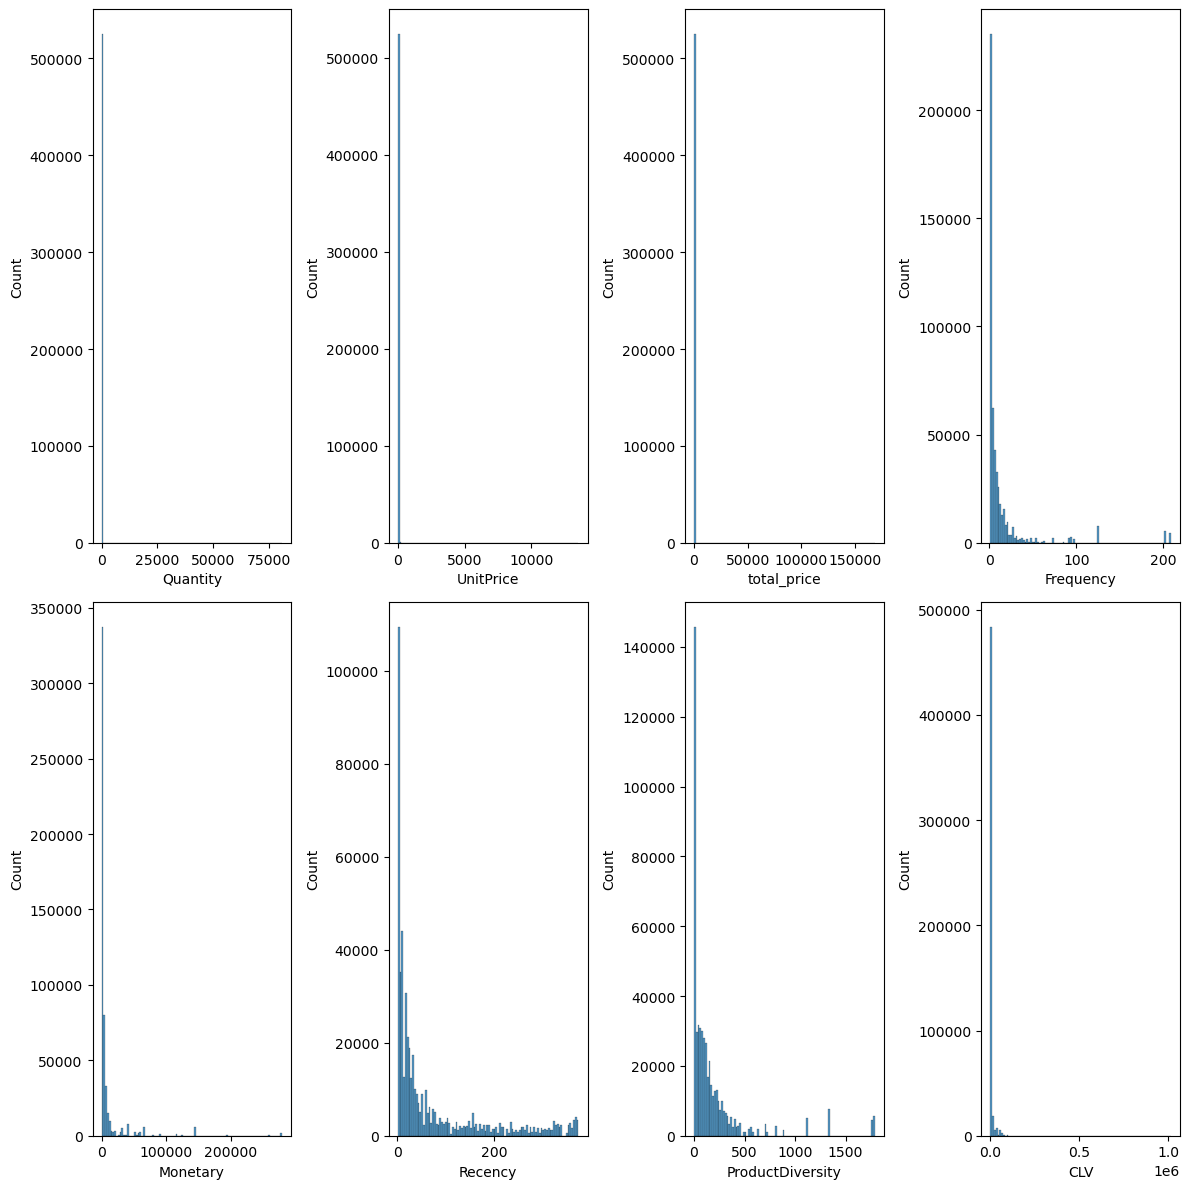

In [87]:
num_cols = ['Quantity', 'UnitPrice', 'total_price', 'Frequency', 'Monetary',
       'Recency','ProductDiversity', 'CLV']
plt.figure(figsize=(12,12))
for i in range(8):
    plt.subplot(2,4,i+1)
    sns.histplot(data=df2,x=num_cols[i],bins=100)
plt.tight_layout()

In [89]:
# all data are skewed

# Apply log1p on train
x_train = np.log1p(x_train)

# Apply log1p on test (using same formula, no fit needed)
x_test = np.log1p(x_test)


y_train= np.log1p(y_train)
y_test= np.log1p(y_test)

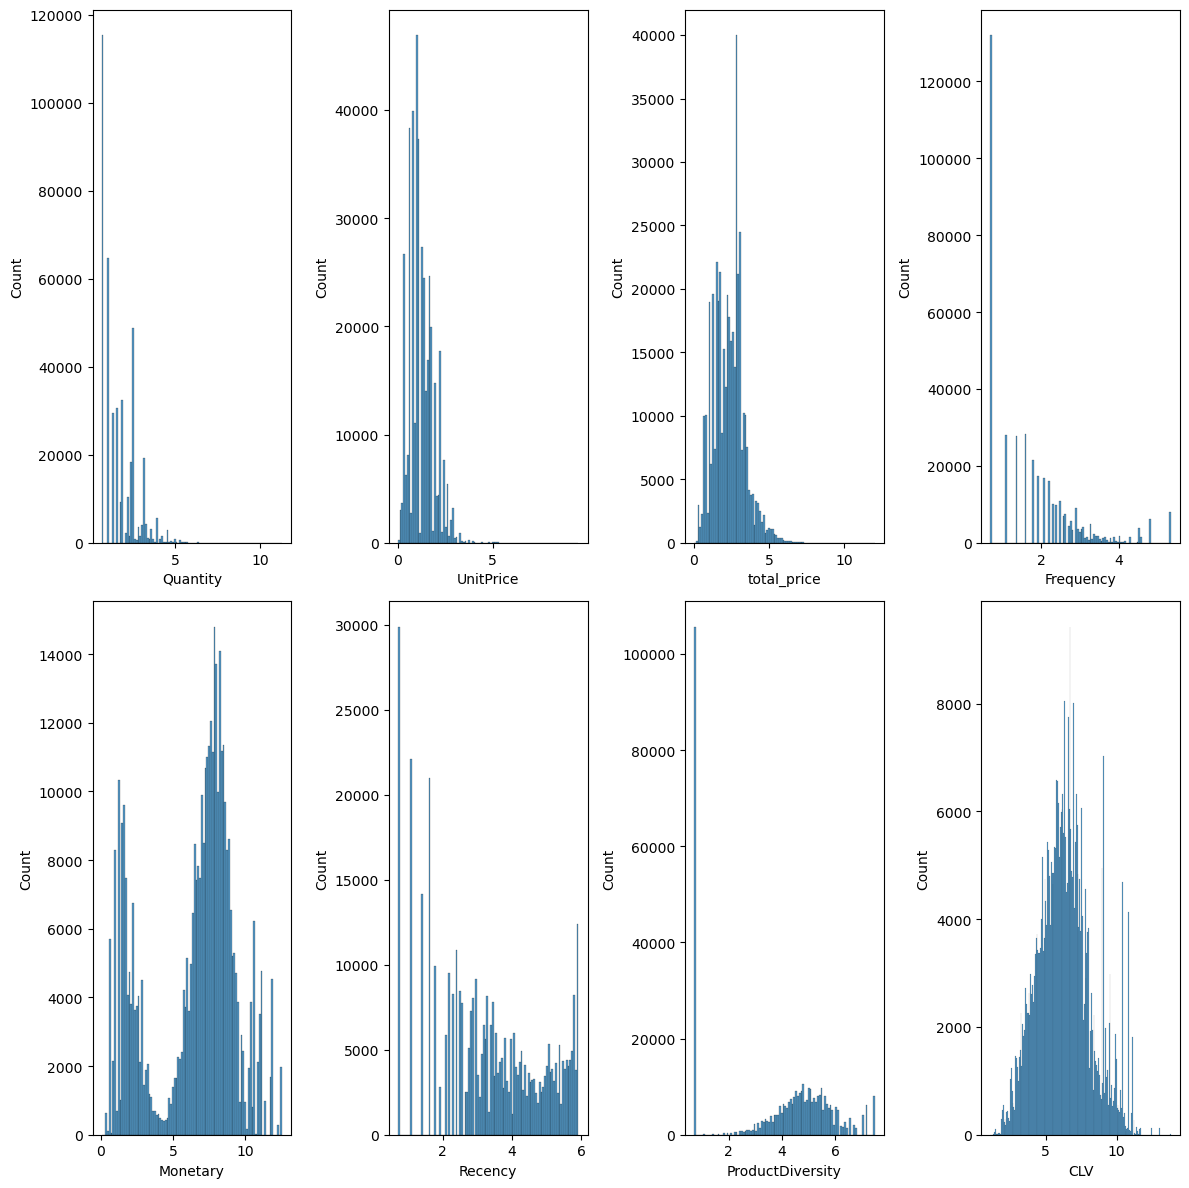

In [44]:
# now data are more normal distributed
num_cols = ['Quantity', 'UnitPrice', 'total_price', 'Frequency', 'Monetary',
       'Recency','ProductDiversity', 'CLV']
plt.figure(figsize=(12,12))
for i in range(7):
    plt.subplot(2,4,i+1)
    sns.histplot(data=x_train,x=num_cols[i],bins=100)
plt.subplot(2,4,8)
sns.histplot(y_train)
plt.tight_layout()
    

In [45]:
x_train.head()

,Quantity,UnitPrice,total_price,Frequency,Monetary,Recency,Country,ProductCategory,ProductDiversity
291727,1.609438,0.350657,0.985817,2.639057,8.523388,3.526361,3.610918,1.791759,5.703782
365923,0.693147,0.810930,0.810930,0.693147,0.810930,4.290459,3.610918,1.609438,0.693147
70577,2.564949,0.810930,2.772589,2.944439,8.388973,1.386294,3.610918,1.386294,5.805135
539925,1.098612,0.896088,1.360977,2.397895,7.087991,0.693147,3.610918,1.609438,4.962845
401623,0.693147,1.635106,1.635106,2.890372,11.084690,1.609438,3.610918,1.609438,7.021084


## Exploratory Data Analysis 

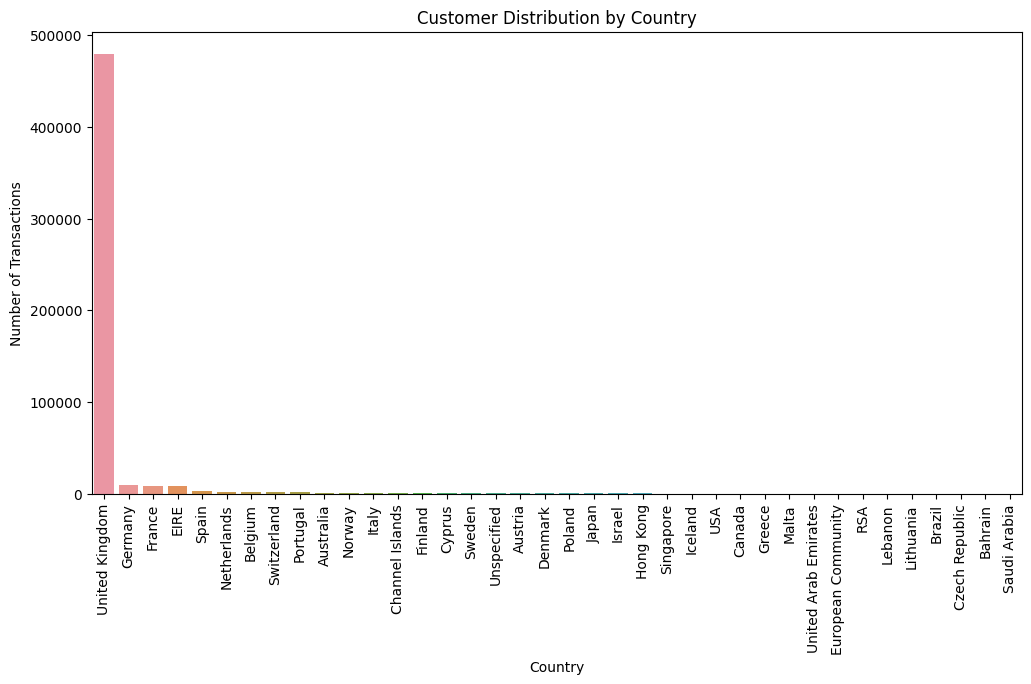

In [49]:
# --- Customer distribution by country ---
plt.figure(figsize=(12,6))
country_counts = df['Country'].value_counts()
sns.barplot(x=country_counts.index, y=country_counts.values)
plt.xticks(rotation=90)
plt.title('Customer Distribution by Country')
plt.ylabel('Number of Transactions')
plt.show()

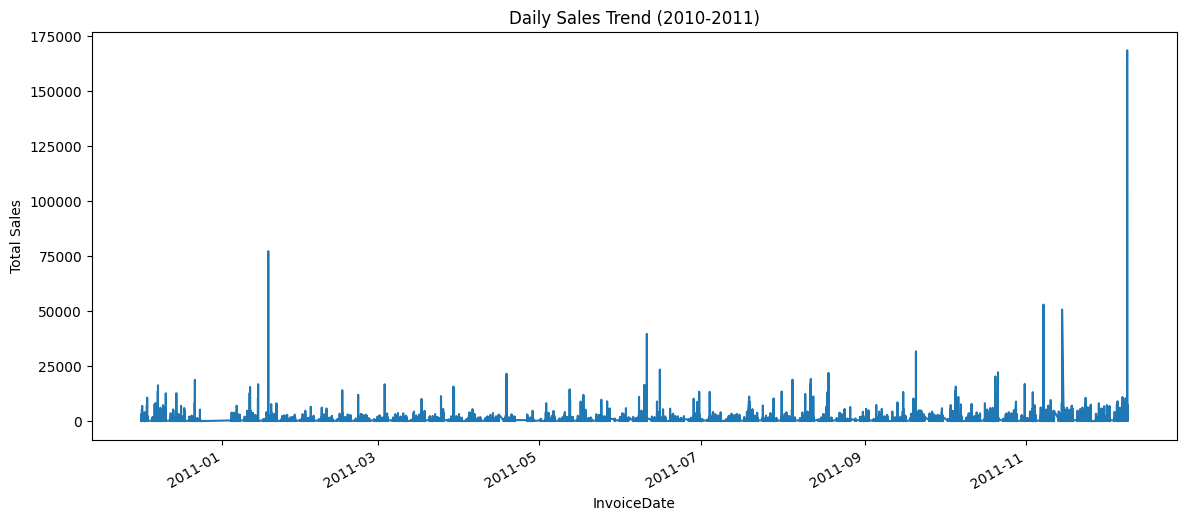

In [50]:
# ---  Time-series analysis of sales trends (2010-2011) ---

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
daily_sales = df.groupby('InvoiceDate')['total_price'].sum()

plt.figure(figsize=(14,6))
daily_sales.plot()
plt.title('Daily Sales Trend (2010-2011)')
plt.ylabel('Total Sales')
plt.show()

### Customer lifetime value distribution and Pareto analysis (80/20 rule) 


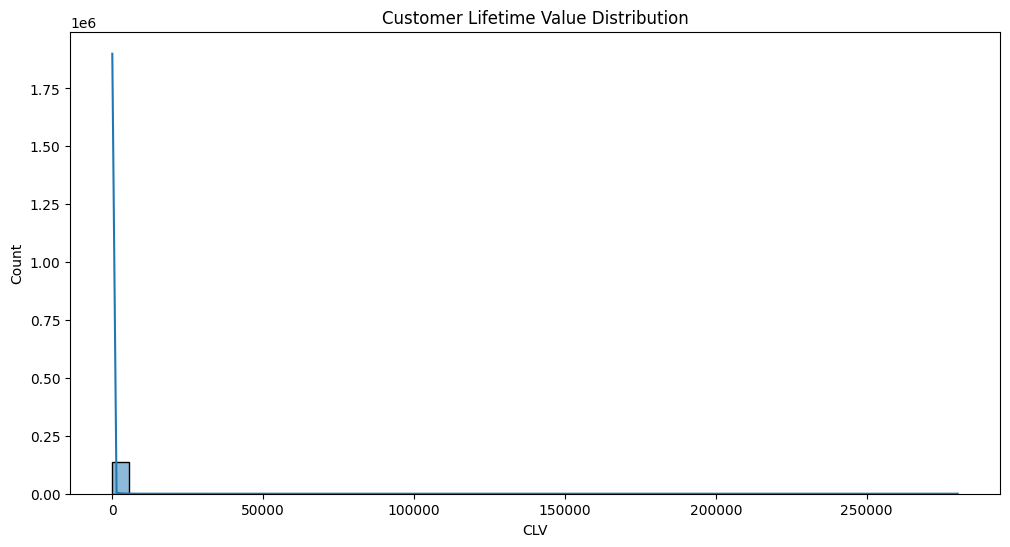

In [51]:
clv_to_customer = df.groupby('CustomerID')['total_price'].sum().sort_values(ascending=False)

plt.figure(figsize=(12,6))
sns.histplot(clv_to_customer, bins=50, kde=True)
plt.title('Customer Lifetime Value Distribution')
plt.xlabel('CLV')
plt.show()

In [52]:
clv_to_customer = df.groupby('CustomerID')['total_price'].sum().sort_values(ascending=False)

total_revenue = clv_to_customer.sum()
top_20 = clv_to_customer.head(int(0.2 * len(clv_to_customer)))

print("Top 20% customers contribute {:.2f}% of revenue".format(
    top_20.sum() / total_revenue * 100
))


Top 20% customers contribute 94.78% of revenue


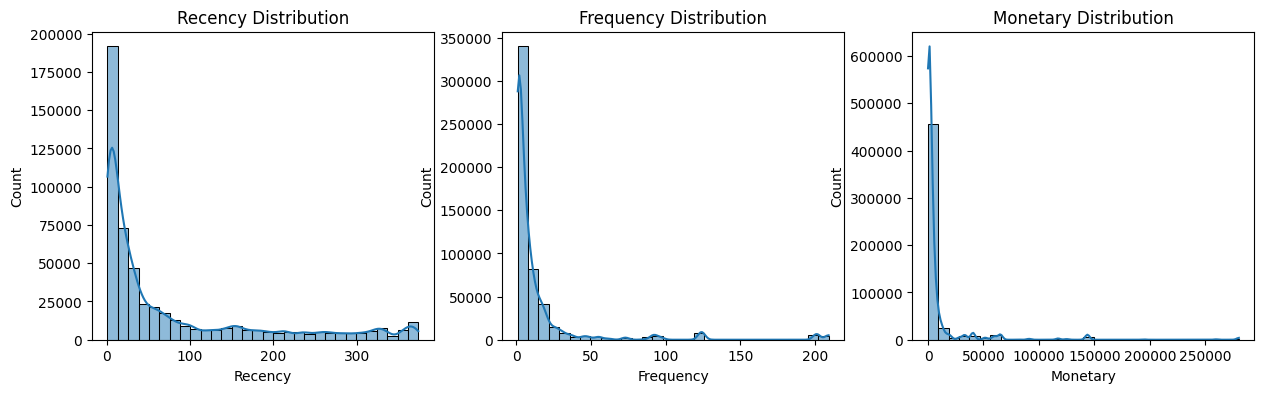

In [53]:
# ---  RFM distributions & correlations ---
plt.figure(figsize=(15,4))
for i, col in enumerate(['Recency','Frequency','Monetary']):
    plt.subplot(1,3,i+1)
    sns.histplot(df[col], bins=30, kde=True)
    plt.title(f'{col} Distribution')
plt.show()

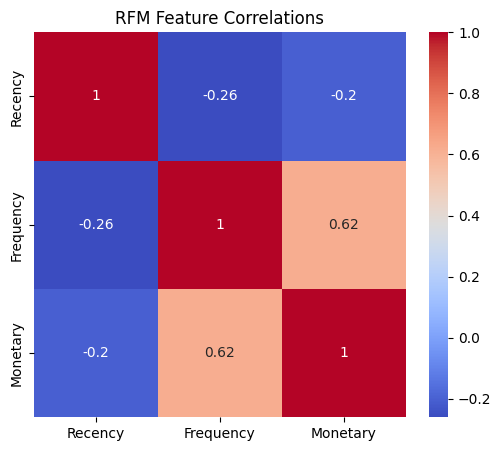

In [54]:
# Correlation matrix
plt.figure(figsize=(6,5))
sns.heatmap(df[['Recency','Frequency','Monetary']].corr(), annot=True, cmap='coolwarm')
plt.title('RFM Feature Correlations')
plt.show()

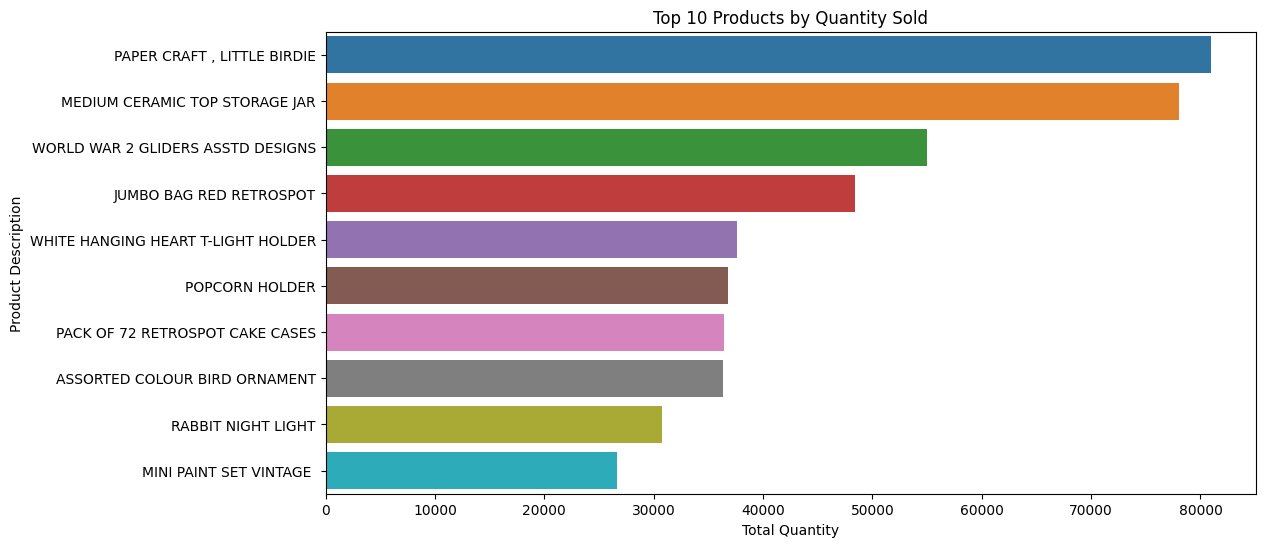

In [55]:
 #  Product popularity using StockCode & Description 
top_products = df.groupby(['StockCode','Description'])['Quantity'].sum().sort_values(ascending=False).head(10)
top_products = top_products.reset_index()

plt.figure(figsize=(12,6))
sns.barplot(x='Quantity', y='Description', data=top_products, orient='h')
plt.title('Top 10 Products by Quantity Sold')
plt.xlabel('Total Quantity')
plt.ylabel('Product Description')
plt.show()


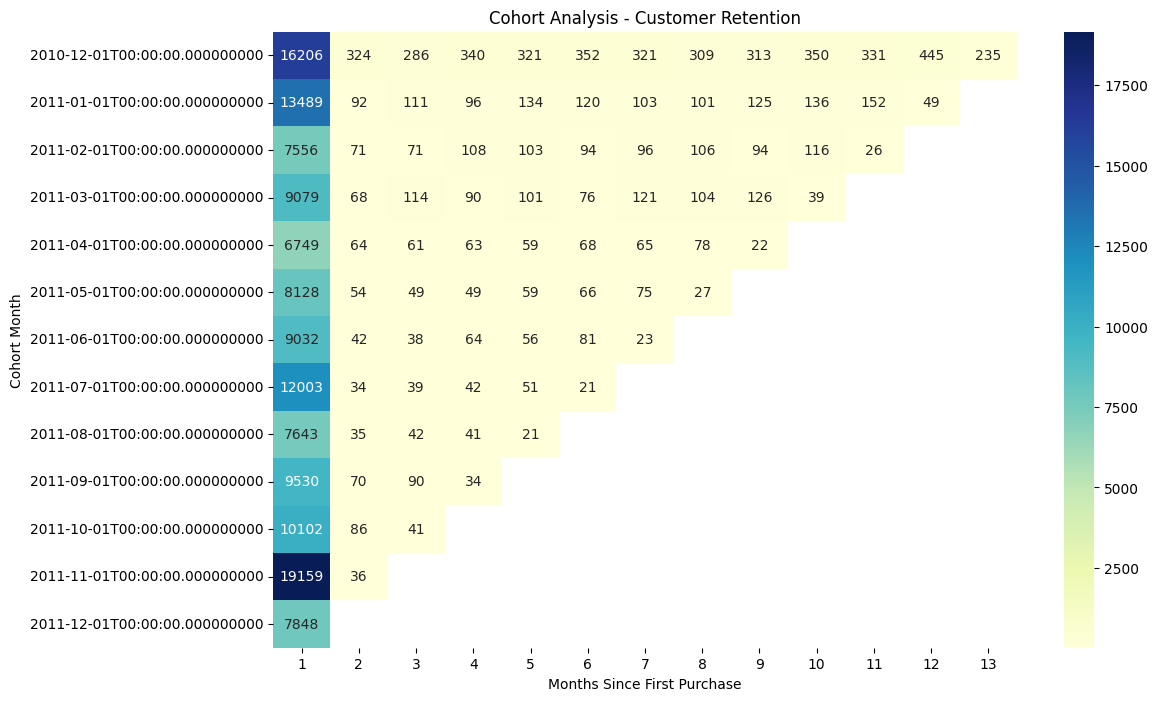

In [65]:
data = df.copy()

data['InvoiceMonth'] = data['InvoiceDate'].dt.to_period('M').dt.to_timestamp()

cohort_min = data.groupby('CustomerID')['InvoiceMonth'].min().reset_index()
cohort_min.rename(columns={'InvoiceMonth':'CohortMonth'}, inplace=True)
data = data.merge(cohort_min, on='CustomerID', how='left')

data['CohortIndex'] = (
    (data['InvoiceMonth'].dt.year - data['CohortMonth'].dt.year) * 12 +
    (data['InvoiceMonth'].dt.month - data['CohortMonth'].dt.month) + 1
)

cohort_counts = data.groupby(['CohortMonth','CohortIndex'])['CustomerID'].nunique().reset_index()
cohort_pivot = cohort_counts.pivot(index='CohortMonth', columns='CohortIndex', values='CustomerID')

# Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(cohort_pivot, annot=True, fmt='.0f', cmap='YlGnBu')
plt.title('Cohort Analysis - Customer Retention')
plt.ylabel('Cohort Month')
plt.xlabel('Months Since First Purchase')
plt.show()


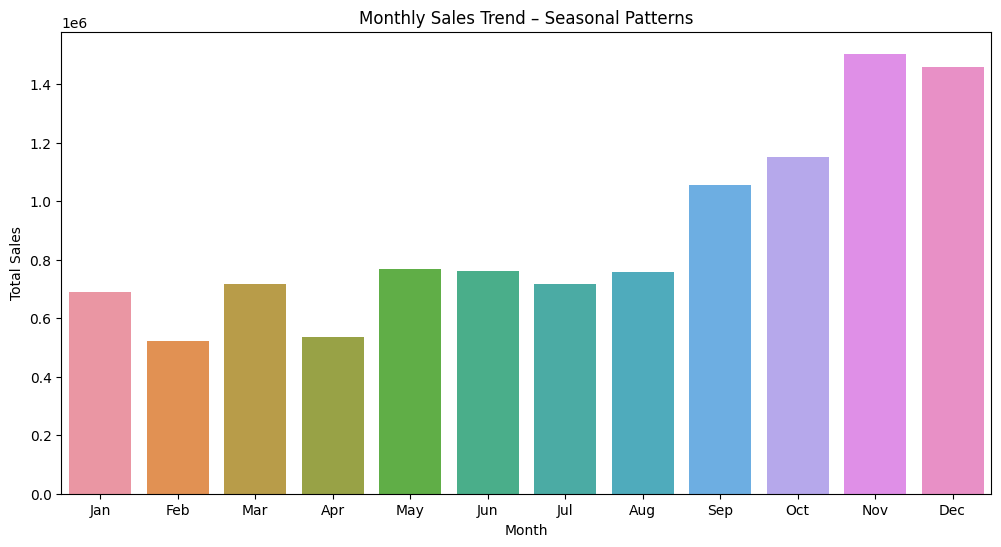

In [66]:
# Extract month name
df['InvoiceMonthNum'] = df['InvoiceDate'].dt.month
df['InvoiceMonthName'] = df['InvoiceDate'].dt.strftime('%b') 

# Aggregate total sales per month
monthly_sales = df.groupby('InvoiceMonthNum')['total_price'].sum()

plt.figure(figsize=(12,6))
sns.barplot(x=monthly_sales.index, y=monthly_sales.values)
plt.xticks(ticks=range(0,12), labels=['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
plt.title('Monthly Sales Trend – Seasonal Patterns')
plt.ylabel('Total Sales')
plt.xlabel('Month')
plt.show()


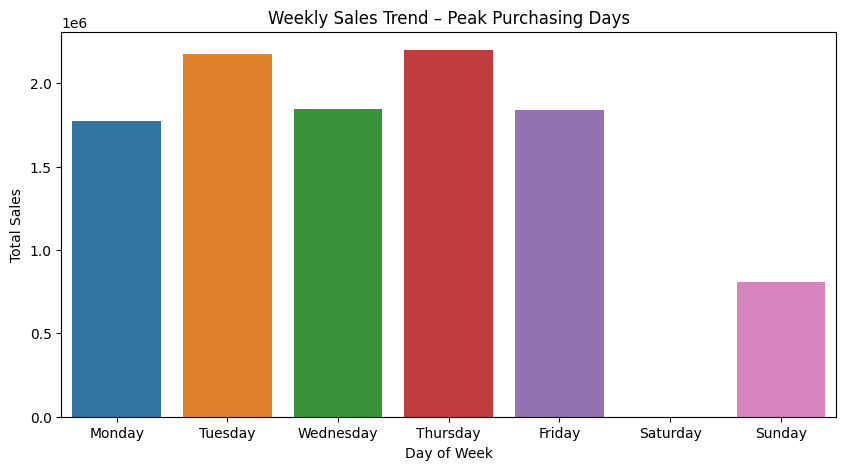

In [67]:

df['DayOfWeek'] = df['InvoiceDate'].dt.day_name()

day_sales = df.groupby('DayOfWeek')['total_price'].sum()
day_sales = day_sales.reindex(['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])

plt.figure(figsize=(10,5))
sns.barplot(x=day_sales.index, y=day_sales.values)
plt.title('Weekly Sales Trend – Peak Purchasing Days')
plt.ylabel('Total Sales')
plt.xlabel('Day of Week')
plt.show()


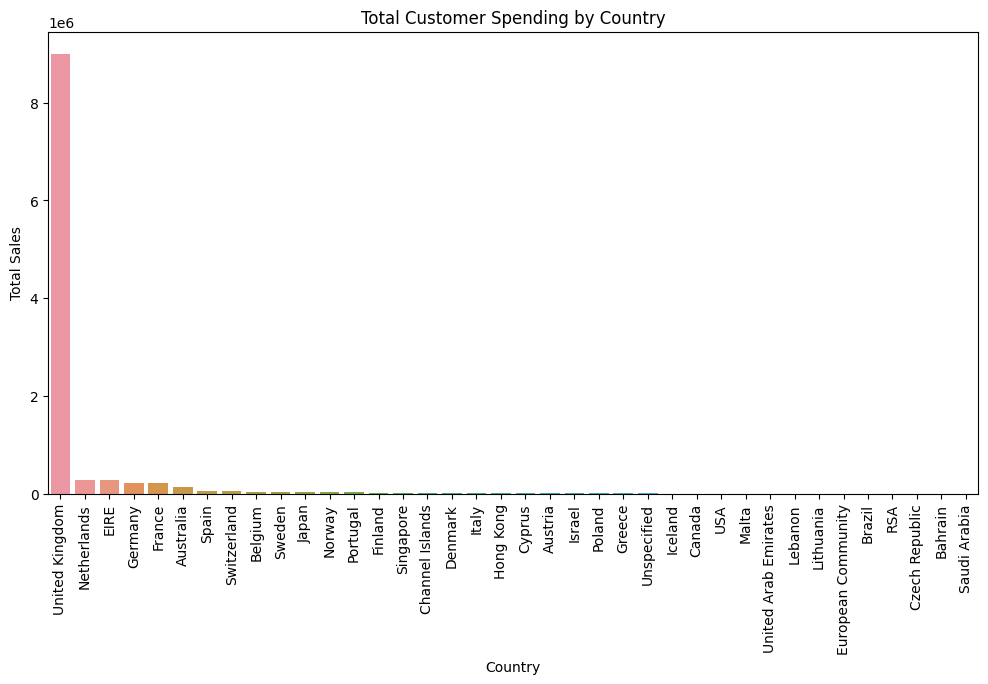

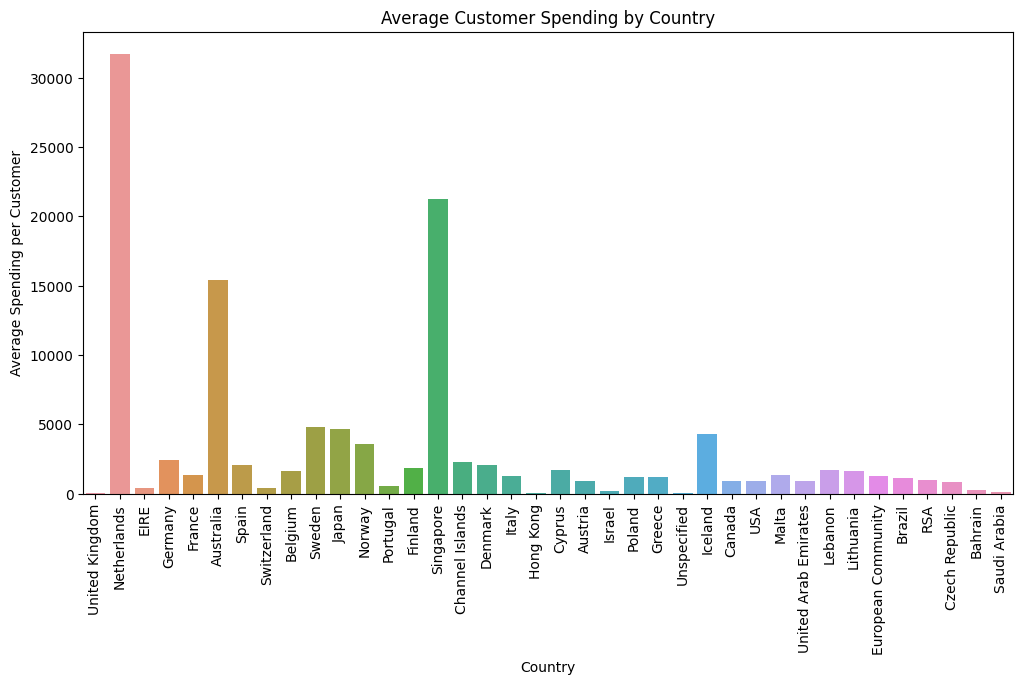

In [69]:
# Aggregate total sales and average spending per customer by country
country_summary = df.groupby('Country').agg(
    TotalSales=('total_price', 'sum'),
    AvgCustomerSpending=('total_price', lambda x: x.groupby(df['CustomerID']).sum().mean())
).sort_values('TotalSales', ascending=False)

# Plot total sales per country
plt.figure(figsize=(12,6))
sns.barplot(x=country_summary.index, y=country_summary['TotalSales'])
plt.xticks(rotation=90)
plt.title('Total Customer Spending by Country')
plt.ylabel('Total Sales')
plt.xlabel('Country')
plt.show()

# Plot average customer spending per country
plt.figure(figsize=(12,6))
sns.barplot(x=country_summary.index, y=country_summary['AvgCustomerSpending'])
plt.xticks(rotation=90)
plt.title('Average Customer Spending by Country')
plt.ylabel('Average Spending per Customer')
plt.xlabel('Country')
plt.show()



# Unsupervised ML

In [11]:
# imports
from datetime import timedelta
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")
import warnings
warnings.filterwarnings("ignore")

In [13]:
# Load data 
try:
    df = pd.read_excel("Online Retail.xlsx")
except:
    df = pd.read_csv("OnlineRetail.csv", encoding="latin1")

df.columns = [c.strip() for c in df.columns]
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"], errors="coerce")
df = df.dropna(subset=["CustomerID"])
df = df[(df["Quantity"] > 0) & (df["UnitPrice"] > 0)]
df["CustomerID"] = df["CustomerID"].astype(int)

df["TotalPrice"] = df["Quantity"] * df["UnitPrice"]    

In [14]:
# RFM
snapshot = df["InvoiceDate"].max() + timedelta(days=1)

rfm = df.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (snapshot - x.max()).days,
    "InvoiceNo": "nunique",
    "TotalPrice": "sum"
}).reset_index()

rfm.rename(columns={
    "InvoiceDate": "Recency",
    "InvoiceNo": "Frequency",
    "TotalPrice": "Monetary"
}, inplace=True)

In [15]:
# log transform
rfm["Frequency_log"] = np.log1p(rfm["Frequency"])
rfm["Monetary_log"] = np.log1p(rfm["Monetary"])

In [16]:
# select final features
X = rfm[["Recency", "Frequency_log", "Monetary_log"]]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [17]:
# SILHOUETTE
print("Silhouette Scores:")
for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f"k={k}: {score:.4f}")

Silhouette Scores:
k=2: 0.4063
k=3: 0.4157
k=4: 0.3792
k=5: 0.3630
k=6: 0.3340
k=7: 0.3278
k=8: 0.2972


In [18]:
# KMEANS (k=5)
kmeans = KMeans(n_clusters=5, random_state=42)
rfm["KMeans_Label"] = kmeans.fit_predict(X_scaled)

In [19]:
# GMM
gmm = GaussianMixture(n_components=5, random_state=42)
gmm.fit(X_scaled)

GaussianMixture(n_components=5, random_state=42)

In [20]:
rfm["GMM_Label"] = gmm.predict(X_scaled)
rfm["GMM_Prob"] = gmm.predict_proba(X_scaled).max(axis=1)

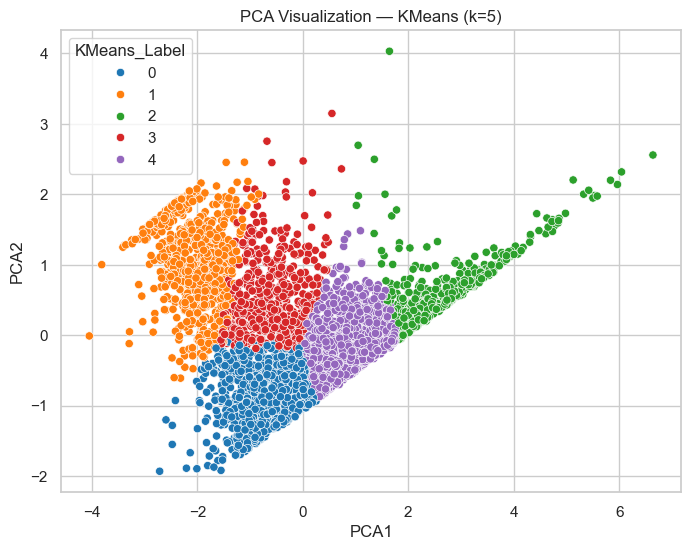

In [22]:
# PCA
pca = PCA(n_components=2, random_state=42)
pca_comp = pca.fit_transform(X_scaled)

rfm["PCA1"] = pca_comp[:, 0]
rfm["PCA2"] = pca_comp[:, 1]

plt.figure(figsize=(8,6))
sns.scatterplot(data=rfm, x="PCA1", y="PCA2", hue="KMeans_Label", palette="tab10")
plt.title("PCA Visualization — KMeans (k=5)")
plt.show()

In [24]:
# BUSINESS CHECK
summary = rfm.groupby("KMeans_Label").agg({
    "Recency": "mean",
    "Frequency": "mean",
    "Monetary": "mean",
    "GMM_Prob": "mean",
    "CustomerID": "count"
}).rename(columns={"CustomerID": "Customers"})

print("\nCluster Business Summary:\n")
print(summary)


Cluster Business Summary:

                 Recency  Frequency      Monetary  GMM_Prob  Customers
KMeans_Label                                                          
0              48.646054   1.472742    365.856022  0.981728       1229
1             278.015965   1.146589    272.253991  0.999975        689
2              19.825427  16.525617  10432.418653  0.926714        527
3             169.932836   2.203358    979.481364  0.998612        536
4              35.778924   4.452469   1659.028159  0.769741       1357


In [25]:
# PERSONAS
print("\nCustomer Personas:\n")

for cluster in sorted(rfm["KMeans_Label"].unique()):
    sub = rfm[rfm["KMeans_Label"] == cluster]

    rec = sub["Recency"].median()
    freq = sub["Frequency"].median()
    mon = sub["Monetary"].median()

    if rec < rfm["Recency"].quantile(0.25) and freq > rfm["Frequency"].quantile(0.75):
        persona = "Active Loyal"
    elif mon > rfm["Monetary"].quantile(0.75):
        persona = "High Value"
    elif rec > rfm["Recency"].quantile(0.75):
        persona = "At Risk"
    else:
        persona = "Occasional"

    print(f"Cluster {cluster}: {persona}")
    print(f" - Recency median: {rec}")
    print(f" - Frequency median: {freq}")
    print(f" - Monetary median: {mon}\n")


Customer Personas:

Cluster 0: Occasional
 - Recency median: 44.0
 - Frequency median: 1.0
 - Monetary median: 324.8

Cluster 1: At Risk
 - Recency median: 277.0
 - Frequency median: 1.0
 - Monetary median: 216.76

Cluster 2: Active Loyal
 - Recency median: 10.0
 - Frequency median: 12.0
 - Monetary median: 4810.9400000000005

Cluster 3: At Risk
 - Recency median: 165.0
 - Frequency median: 2.0
 - Monetary median: 642.2149999999999

Cluster 4: Occasional
 - Recency median: 26.0
 - Frequency median: 4.0
 - Monetary median: 1383.18



In [27]:
# SAVE RESULTS
rfm.to_csv("RFM_Clusters.csv", index=False)
summary.to_csv("ClusterSummary.csv", index=False)

print("Done")

Done


# DL model

In [46]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout
from tensorflow.keras.callbacks import EarlyStopping

#Build DNN regressor with 4 hidden layers (128, 64, 32, 16 neurons) 

model=Sequential()

#hidden layer
model.add(Dense(128, activation='relu', input_dim=x_train.shape[1]))
model.add(BatchNormalization())
model.add(Dropout(0.3))

model.add(Dense(64, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.3))
          
model.add(Dense(32, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.3))

model.add(Dense(16, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.3))
          
#output layer
model.add(Dense(1, activation='relu')) #to make sure all values are positive 

In [47]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,121 (51.25 KB)

 Trainable params: 12,641 (49.38 KB)

 Non-trainable params: 480 (1.88 KB)

In [48]:
# Compile the model
model.compile(optimizer='adam', loss='mse', metrics=['root_mean_squared_error'])

In [49]:
#implement Early stopping 
from tensorflow.keras.callbacks import EarlyStopping,ModelCheckpoint
early_stop=EarlyStopping( 
    monitor='val_root_mean_squared_error',
    patience=5,
    restore_best_weights=True
)

In [50]:
##model fitting
history = model.fit(
    x_train,
    y_train,
    validation_split=0.2, 
    epochs=100,
    batch_size=64,
    callbacks=[early_stop],  
)

Epoch 1/100
5249/5249 ━━━━━━━━━━━━━━━━━━━━ 35s 5ms/step - loss: 3.4454 - root_mean_squared_error: 1.8562 - val_loss: 0.4691 - val_root_mean_squared_error: 0.6849
Epoch 2/100
5249/5249 ━━━━━━━━━━━━━━━━━━━━ 27s 5ms/step - loss: 1.0881 - root_mean_squared_error: 1.0431 - val_loss: 0.4251 - val_root_mean_squared_error: 0.6520
Epoch 3/100
5249/5249 ━━━━━━━━━━━━━━━━━━━━ 28s 5ms/step - loss: 0.7547 - root_mean_squared_error: 0.8687 - val_loss: 0.3685 - val_root_mean_squared_error: 0.6071
Epoch 4/100
5249/5249 ━━━━━━━━━━━━━━━━━━━━ 24s 5ms/step - loss: 0.6416 - root_mean_squared_error: 0.8010 - val_loss: 0.2942 - val_root_mean_squared_error: 0.5424
Epoch 5/100
5249/5249 ━━━━━━━━━━━━━━━━━━━━ 26s 5ms/step - loss: 0.5940 - root_mean_squared_error: 0.7707 - val_loss: 0.3729 - val_root_mean_squared_error: 0.6107
Epoch 6/100
5249/5249 ━━━━━━━━━━━━━━━━━━━━ 27s 5ms/step - loss: 0.5716 - root_mean_squared_error: 0.7560 - val_loss: 0.3084 - val_root_mean_squared_error: 0.5554
Epoch 7/100
5249/5249 ━━━━━━

In [51]:
y_pred= model.predict(x_test)

3281/3281 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step  


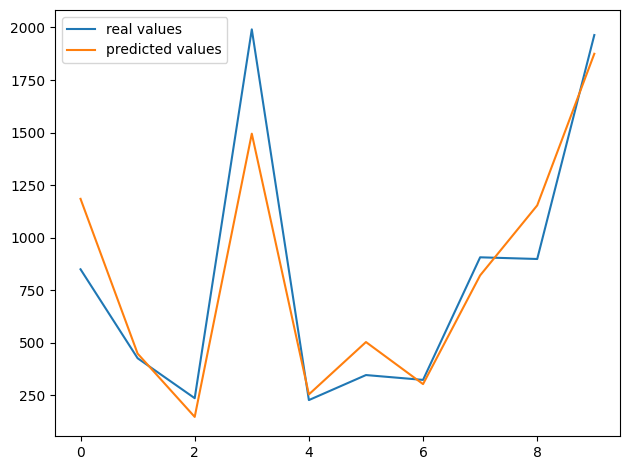

In [289]:
plt.plot(np.round(np.expm1(y_test[:10].values).reshape(-1)),label='real values')
plt.plot(np.round(np.expm1(y_pred[:10]).reshape(-1)),label='predicted values')
plt.tight_layout()
plt.legend()
plt.show()

In [52]:
from sklearn.metrics import mean_absolute_error,mean_squared_error
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test,y_pred)
print("MAE:", mae)
print("RMSE:" , np.sqrt(mse))

MAE: 0.292806383876535
RMSE: 0.5389143351515608


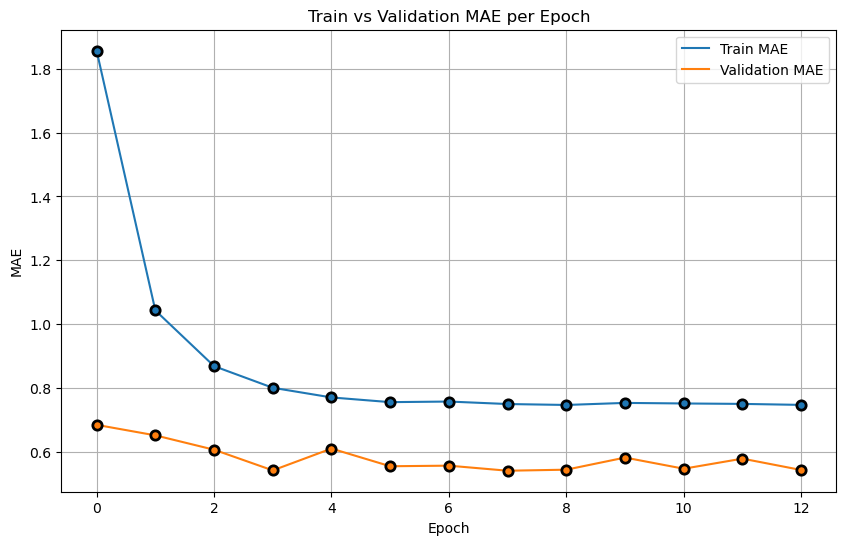

In [53]:

plt.figure(figsize=(10,6))
plt.plot(history.history['root_mean_squared_error'], label='Train MAE')
plt.scatter(np.arange(len(history.history['loss']),dtype='int'),history.history['root_mean_squared_error'],edgecolor='k',zorder=2,s=45,linewidth=2)
plt.plot(history.history['val_root_mean_squared_error'], label='Validation MAE')
plt.scatter(np.arange(len(history.history['loss']),dtype='int'),history.history['val_root_mean_squared_error'],edgecolor='k',zorder=2,s=45,linewidth=2)
plt.title('Train vs Validation MAE per Epoch')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.grid(True)
plt.show()

In [54]:
print("error percentage")
print("train->",model.evaluate(x_train,y_train,verbose=0)[1] / (y_train.max() - y_train.min())*100)
print("test->",model.evaluate(x_test,y_test,verbose=0)[1] / (y_test.max() - y_test.min())*100)

error percentage
train-> 4.221045026115981
test-> 4.226760458354771


# Build AutoEncoder

In [141]:
autoencoder = Sequential([
    Flatten(input_shape=(9,)),
    
    Dense(9,activation='relu'),
    BatchNormalization(),
    Dropout(.3),
    
    Dense(32,activation='relu'),
    BatchNormalization(),
    Dropout(.3),
    
    Dense(16,activation='relu'),
    BatchNormalization(),
    Dropout(.3),
    
    Dense(8,activation='relu'),
    BatchNormalization(),
    Dropout(.3),
    
    Dense(16,activation='relu'),
    BatchNormalization(),
    Dropout(.3),
    
    Dense(32,activation='relu'),
    BatchNormalization(),
    Dropout(.3),
    
    Dense(9,activation='relu'),
])
autoencoder.compile(
    optimizer='adam',
    loss='mse',
    metrics=['root_mean_squared_error']
)

In [142]:
autoencoder.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 9)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 9)              │            90 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 9)              │            36 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 9)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 32)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 8)              │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 9)              │           297 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,511 (9.81 KB)

 Trainable params: 2,285 (8.93 KB)

 Non-trainable params: 226 (904.00 B)

In [143]:
early_stop2 = EarlyStopping(
    monitor='val_root_mean_squared_error',
    patience=5,
    restore_best_weights=True,
)
autoencoder.fit(x_train,x_train,
                 epochs=100,
                 validation_split=.2,
                 batch_size=64,
                 callbacks=[early_stop2])

Epoch 1/100
5249/5249 ━━━━━━━━━━━━━━━━━━━━ 22s 3ms/step - loss: 1.3508 - root_mean_squared_error: 1.1623 - val_loss: 0.5082 - val_root_mean_squared_error: 0.7129
Epoch 2/100
5249/5249 ━━━━━━━━━━━━━━━━━━━━ 18s 3ms/step - loss: 0.7172 - root_mean_squared_error: 0.8469 - val_loss: 0.5042 - val_root_mean_squared_error: 0.7101
Epoch 3/100
5249/5249 ━━━━━━━━━━━━━━━━━━━━ 19s 4ms/step - loss: 0.6468 - root_mean_squared_error: 0.8043 - val_loss: 0.4968 - val_root_mean_squared_error: 0.7048
Epoch 4/100
5249/5249 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - loss: 0.6162 - root_mean_squared_error: 0.7850 - val_loss: 0.5115 - val_root_mean_squared_error: 0.7152
Epoch 5/100
5249/5249 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - loss: 0.6011 - root_mean_squared_error: 0.7753 - val_loss: 0.4967 - val_root_mean_squared_error: 0.7047
Epoch 6/100
5249/5249 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - loss: 0.5904 - root_mean_squared_error: 0.7684 - val_loss: 0.5147 - val_root_mean_squared_error: 0.7175
Epoch 7/100
5249/5249 ━━━━━━

In [144]:
# extract the encoder part
autoEncoderModel = Sequential(autoencoder.layers[:-7])
for layer in autoEncoderModel.layers:
    layer.freeze=True

In [145]:
encoderModel = Sequential([
    autoEncoderModel,
    Dense(64,activation='relu'),
    BatchNormalization(),
    Dropout(.3),
    
    Dense(32,activation='relu'),
    BatchNormalization(),
    Dropout(.3),

    Dense(16,activation='relu'),
    BatchNormalization(),
    Dropout(.3),
    
    Dense(1,activation='relu'),
])
encoderModel.compile(
    optimizer='adam',
    loss='mse',
    metrics=['root_mean_squared_error']
)

In [146]:
encoderModel.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_7 (Sequential)       │ (None, 8)              │         1,334 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_24          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_25          │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_26          │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,983 (19.46 KB)

 Trainable params: 4,629 (18.08 KB)

 Non-trainable params: 354 (1.38 KB)

In [147]:
hist = encoderModel.fit(x_train,y_train,
                 epochs=100,
                 validation_split=.2,
                 batch_size=64,
                 callbacks=[early_stop2])

Epoch 1/100
5249/5249 ━━━━━━━━━━━━━━━━━━━━ 24s 3ms/step - loss: 4.0586 - root_mean_squared_error: 2.0146 - val_loss: 1.3867 - val_root_mean_squared_error: 1.1776
Epoch 2/100
5249/5249 ━━━━━━━━━━━━━━━━━━━━ 21s 4ms/step - loss: 1.9055 - root_mean_squared_error: 1.3804 - val_loss: 1.4492 - val_root_mean_squared_error: 1.2038
Epoch 3/100
5249/5249 ━━━━━━━━━━━━━━━━━━━━ 19s 4ms/step - loss: 1.3962 - root_mean_squared_error: 1.1816 - val_loss: 0.9324 - val_root_mean_squared_error: 0.9656
Epoch 4/100
5249/5249 ━━━━━━━━━━━━━━━━━━━━ 18s 3ms/step - loss: 1.2380 - root_mean_squared_error: 1.1127 - val_loss: 0.8878 - val_root_mean_squared_error: 0.9422
Epoch 5/100
5249/5249 ━━━━━━━━━━━━━━━━━━━━ 18s 3ms/step - loss: 1.1796 - root_mean_squared_error: 1.0861 - val_loss: 0.7956 - val_root_mean_squared_error: 0.8920


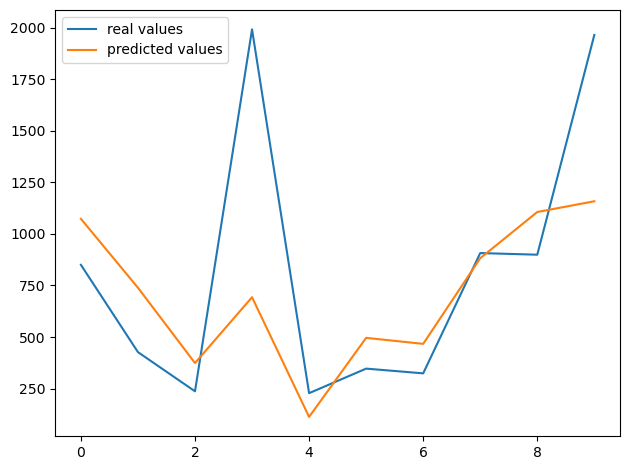

In [148]:
plt.plot(np.round(np.expm1(y_test[:10].values).reshape(-1)),label='real values')
plt.plot(np.round(np.expm1(encoderModel.predict(x_test,verbose=0)[:10]).reshape(-1)),label='predicted values')
plt.tight_layout()
plt.legend()
plt.show()

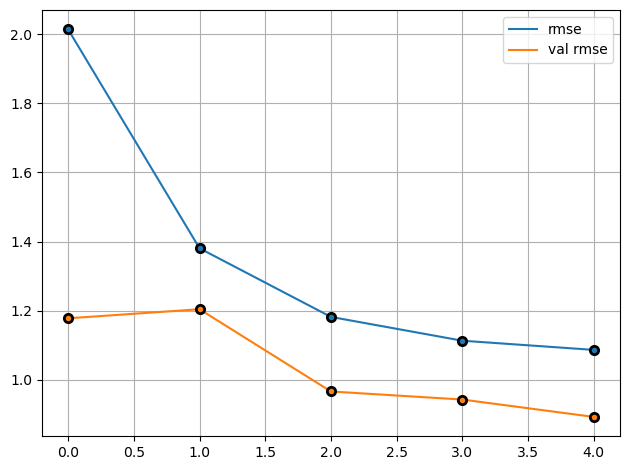

In [149]:
temp = np.arange(len(hist.history['loss']))
plt.plot(hist.history['root_mean_squared_error'],label='rmse')
plt.scatter(temp,hist.history['root_mean_squared_error'],edgecolor='k',zorder=2,linewidth=2)
plt.plot(hist.history['val_root_mean_squared_error'],label='val rmse')
plt.scatter(temp,hist.history['val_root_mean_squared_error'],edgecolor='k',zorder=2,linewidth=2)
plt.tight_layout()
plt.legend()
plt.grid()
plt.show()

In [173]:
print("Error percentage")
print("train->",round(encoderModel.evaluate(x_train,y_train,verbose=0)[1] / (y_train.max() - y_train.min())*100,2),"%")
print("test->",round(encoderModel.evaluate(x_test,y_test,verbose=0)[1] / (y_test.max() - y_test.min())*100,2),"%")

Error percentage
train-> 9.24 %
test-> 9.23 %


In [140]:
import tensorflow as tf
tf.keras.models.save_model(model,'model_DNN.h5')
tf.keras.models.save_model(encoderModel,'enc_model_DNN.h5')

In [319]:
df2.to_csv('ready_data',index=False)

# Emedding Model

In [111]:
embd_model = Sequential([
    Dense(9,activation='relu',input_shape=(9,)),
    BatchNormalization(),
    Dropout(.3),
    
    Dense(32,activation='relu'),
    BatchNormalization(),
    Dropout(.3),
    
    Dense(16,activation='relu'),
    BatchNormalization(),
    Dropout(.3),
    
    Dense(8,activation='relu'),
    BatchNormalization(),
    Dropout(.3),


    Dense(1,activation=('relu')),
])
embd_model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['root_mean_squared_error']
)


In [113]:
embd_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_11 (Dense)                │ (None, 9)              │            90 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 9)              │            36 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 9)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 32)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 8)              │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,343 (5.25 KB)

 Trainable params: 1,213 (4.74 KB)

 Non-trainable params: 130 (520.00 B)

In [115]:
early_stop = EarlyStopping(
    monitor='val_root_mean_squared_error',
    patience=5,
    restore_best_weights=True,
)

embd_model.fit(x_train,
               y_train,
               epochs=100,
               validation_split=.2,
               callbacks=[early_stop])

Epoch 1/100
10498/10498 ━━━━━━━━━━━━━━━━━━━━ 34s 3ms/step - loss: 3.9627 - root_mean_squared_error: 1.9906 - val_loss: 1.0462 - val_root_mean_squared_error: 1.0229
Epoch 2/100
10498/10498 ━━━━━━━━━━━━━━━━━━━━ 30s 3ms/step - loss: 1.3298 - root_mean_squared_error: 1.1532 - val_loss: 0.7152 - val_root_mean_squared_error: 0.8457
Epoch 3/100
10498/10498 ━━━━━━━━━━━━━━━━━━━━ 30s 3ms/step - loss: 1.1125 - root_mean_squared_error: 1.0548 - val_loss: 0.6100 - val_root_mean_squared_error: 0.7810
Epoch 4/100
10498/10498 ━━━━━━━━━━━━━━━━━━━━ 28s 3ms/step - loss: 1.0314 - root_mean_squared_error: 1.0156 - val_loss: 0.5821 - val_root_mean_squared_error: 0.7630
Epoch 5/100
10498/10498 ━━━━━━━━━━━━━━━━━━━━ 30s 3ms/step - loss: 1.0008 - root_mean_squared_error: 1.0004 - val_loss: 0.6230 - val_root_mean_squared_error: 0.7893
Epoch 6/100
10498/10498 ━━━━━━━━━━━━━━━━━━━━ 29s 3ms/step - loss: 0.9879 - root_mean_squared_error: 0.9939 - val_loss: 0.6466 - val_root_mean_squared_error: 0.8041
Epoch 7/100
1049

In [116]:
embd_model.evaluate(x_test,y_test)

3281/3281 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - loss: 0.5826 - root_mean_squared_error: 0.7633


[0.5825932621955872, 0.7632779479026794]

In [117]:
embd_predictor = Sequential(embd_model.layers[:-1])
for lay in embd_predictor.layers:
    lay.trainable=False
embd_predictor.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_11 (Dense)                │ (None, 9)              │            90 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 9)              │            36 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 9)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 32)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 8)              │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 8)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,334 (5.21 KB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 1,334 (5.21 KB)

In [118]:
def to_embd_data(data):
    temp_pred = embd_predictor.predict(data,verbose=0)
    temp_df1 = data.copy().reset_index().drop('index',axis=1)
    temp_df2 = pd.DataFrame(temp_pred,columns = [f"embd_x{i+1}" for i in range(8)])
    return pd.concat((temp_df1,temp_df2),axis=1)

In [128]:
x_train_embd = to_embd_data(x_train)

In [129]:
x_train_embd.head()

,Quantity,UnitPrice,total_price,Frequency,Monetary,Recency,Country,ProductCategory,ProductDiversity,embd_x1,embd_x2,embd_x3,embd_x4,embd_x5,embd_x6,embd_x7,embd_x8
0,1.609438,0.350657,0.985817,2.639057,8.523388,3.526361,3.610918,1.791759,5.703782,-0.123724,0.179107,0.110253,-0.235048,0.104339,-0.144993,-0.076804,0.149348
1,0.693147,0.810930,0.810930,0.693147,0.810930,4.290459,3.610918,1.609438,0.693147,0.881513,-0.731561,-0.887059,0.678330,-0.900039,0.638628,0.991358,-0.736167
2,2.564949,0.810930,2.772589,2.944439,8.388973,1.386294,3.610918,1.386294,5.805135,-0.298690,0.394682,0.202340,-0.389036,0.209780,-0.317018,-0.220676,0.274919
3,1.098612,0.896088,1.360977,2.397895,7.087991,0.693147,3.610918,1.609438,4.962845,-0.010638,-0.025904,0.039512,-0.131465,0.019834,-0.031144,0.017208,0.038809
4,0.693147,1.635106,1.635106,2.890372,11.084690,1.609438,3.610918,1.609438,7.021084,-1.230015,1.191283,0.981471,-0.613596,0.957361,-0.782353,-1.614951,1.014934


In [130]:
embedding = Sequential([
    Dense(128,activation='relu',input_shape=(17,)),
    BatchNormalization(),
    Dropout(.3),
    
    Dense(64,activation='relu'),
    BatchNormalization(),
    Dropout(.3),


    Dense(32,activation='relu'),
    BatchNormalization(),
    Dropout(.3),
    
    Dense(16,activation='relu'),
    BatchNormalization(),
    Dropout(.3),
    
    Dense(8,activation='relu'),
    BatchNormalization(),
    Dropout(.3),


    Dense(1,activation=('relu')),
])
embedding.compile(
    optimizer='adam',
    loss='mse',
    metrics=['root_mean_squared_error']
)

In [131]:
embedding.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_16 (Dense)                │ (None, 128)            │         2,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 8)              │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,305 (55.88 KB)

 Trainable params: 13,809 (53.94 KB)

 Non-trainable params: 496 (1.94 KB)

In [132]:
early_stop = EarlyStopping(
    monitor='val_root_mean_squared_error',
    patience=5,
    restore_best_weights=True,
)

history = embedding.fit(
    x_train_embd,
    y_train,
    epochs=100,
    validation_split=.2,
    callbacks=[early_stop]
)

Epoch 1/100
10498/10498 ━━━━━━━━━━━━━━━━━━━━ 37s 3ms/step - loss: 3.1280 - root_mean_squared_error: 1.7686 - val_loss: 0.4198 - val_root_mean_squared_error: 0.6479
Epoch 2/100
10498/10498 ━━━━━━━━━━━━━━━━━━━━ 33s 3ms/step - loss: 0.9192 - root_mean_squared_error: 0.9587 - val_loss: 0.3827 - val_root_mean_squared_error: 0.6186
Epoch 3/100
10498/10498 ━━━━━━━━━━━━━━━━━━━━ 33s 3ms/step - loss: 0.7492 - root_mean_squared_error: 0.8655 - val_loss: 0.3424 - val_root_mean_squared_error: 0.5852
Epoch 4/100
10498/10498 ━━━━━━━━━━━━━━━━━━━━ 33s 3ms/step - loss: 0.7228 - root_mean_squared_error: 0.8501 - val_loss: 0.3574 - val_root_mean_squared_error: 0.5978
Epoch 5/100
10498/10498 ━━━━━━━━━━━━━━━━━━━━ 31s 3ms/step - loss: 0.7224 - root_mean_squared_error: 0.8500 - val_loss: 0.3707 - val_root_mean_squared_error: 0.6088
Epoch 6/100
10498/10498 ━━━━━━━━━━━━━━━━━━━━ 32s 3ms/step - loss: 0.7115 - root_mean_squared_error: 0.8435 - val_loss: 0.3580 - val_root_mean_squared_error: 0.5983
Epoch 7/100
1049

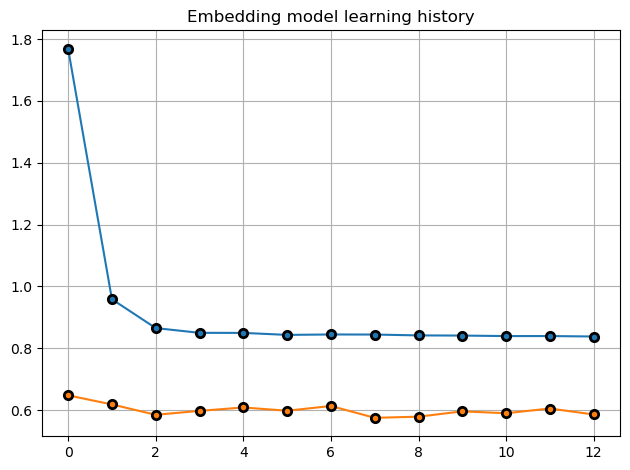

In [133]:
temp = np.arange(len(history.history['loss']))
hs = history.history
plt.title('Embedding model learning history')
plt.plot(hs['root_mean_squared_error'])
plt.scatter(temp,hs['root_mean_squared_error'],edgecolor='k',zorder=2,linewidth=2)
plt.plot(hs['val_root_mean_squared_error'])
plt.scatter(temp,hs['val_root_mean_squared_error'],edgecolor='k',zorder=2,linewidth=2)
plt.tight_layout()
plt.grid()
plt.show()

In [134]:
x_test_embd = to_embd_data(x_test)
embedding.evaluate(x_test_embd,y_test)

3281/3281 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - loss: 0.3292 - root_mean_squared_error: 0.5738


[0.32924261689186096, 0.5737966895103455]

In [167]:
print("Error percentege")
print("Training error : ",round(embedding.evaluate(x_train_embd,y_train,verbose=0)[1] / (y_train.max() - y_train.min()) * 100,2) , "%")
print("Training error : ",round(embedding.evaluate(x_test_embd,y_test,verbose=0)[1] / (y_test.max() - y_test.min())* 100 ,2), "%")

Error percentege
Training error :  4.5 %
Training error :  4.5 %


In [169]:
import tensorflow.keras.models as models
models.save_model(embd_predictor,'feature_generator.keras')
models.save_model(embedding,'Embedding_model.keras')